# Training Problems and Solutions

A falling training loss does not always mean a useful model. We will diagnose an unstable update, a model too simple for its task, and a model that fits noise. Small arithmetic demonstrations then reveal weak and oversized gradients.

Everything runs on CPU using locally generated data, PyTorch, NumPy, and Matplotlib. Use the [README setup](README.md), restart the kernel, and run all cells in order. The [illustrated notes](10_Training_Problems_and_Solutions_Notes.ipynb) explain each idea independently. These controlled demonstrations are not a benchmark, and their validation results are diagnostic rather than final test estimates.

## Start with the problem this lesson solves

When an ANN learns poorly, “add more layers” is not a diagnosis. Exploding loss, high training loss, and low training loss with poor validation performance are different symptoms. We need to trace the mechanism so the repair addresses the cause.

The examples below separate three failures: unstable numerical steps, insufficient representational capacity, and fitting noise. Each can prevent the network from solving the intended prediction problem even when the training code runs.

## Trace a failure before choosing a repair

**An oversized update caused by input scale.** In a one-example miniature, predict $\hat y=wx$ for input $x=1000$ and target two. Start $w=0$ and use $L=\tfrac12(\hat y-2)^2$. Prediction is zero, error is $-2$, and loss is two. The gradient is error times input: $(-2)(1000)=-2000$.

At learning rate $0.1$, $w'=0-0.1(-2000)=200$. New prediction is $200(1000)=200,000$, error is $199,998$, and loss is $\tfrac12(199,998)^2=19,999,600,002$. The large numerical input multiplies the gradient, then multiplies the changed weight again during prediction.

**Repair the scale:** use $x'=x/1000=1$, with a newly initialized weight $a=0$. The target stays two. Its gradient is $(-2)(1)=-2$, so $a'=0.2$, prediction becomes $0.2$, and loss becomes $\tfrac12(-1.8)^2=1.62$. The same rate now gives a useful step. The fitted weights have different units: equivalent predictions satisfy $a=1000w$.

**Alternatively repair the step:** keep $x=1000$ but use rate $10^{-7}$. Then $w'=0.0002$, prediction is $0.2$, and loss is again $1.62$. We have demonstrated the mechanism, not a universal choice of learning rate.

**A different failure: the wrong function family.** For targets $y=x^2$ at $x=[-1,0,1]$, labels are $[1,0,1]$. A line $ax+b$ fitting both outer points must satisfy $-a+b=1$ and $a+b=1$, forcing $a=0,b=1$; it then predicts one at zero instead of zero. No optimizer can remove this contradiction while staying within straight lines. A designed feature $x^2$ solves it directly, or a nonlinear ANN can learn a suitable approximation.

**A third failure: learning the noise.** Suppose training MSE falls from $0.10$ to $0.01$, but validation MSE rises from $0.12$ to $0.30$. The later state fits training data better yet predicts separate examples worse. Keeping the earlier checkpoint addresses model selection; scaling inputs is not an explanation for this particular evidence. These numbers are an illustrative diagnostic, not a saved training result.

## Why understanding the cause changes the remedy

Use scaling or a smaller rate when updates are numerically unstable. Improve features or model capacity when the available function family cannot express the pattern. Consider more representative data, regularization, or earlier checkpoints when generalization deteriorates.

Other mechanisms have equally concrete signs: a negative ReLU score passes zero gradient along that path; repeated small derivatives can diminish gradients; repeated large ones can amplify them. Clipping limits gradient magnitude but does not repair incorrect labels or an unsuitable model. A tiny-batch fit can verify that a basic learning path works, while validation is still needed to judge usefulness.

## Connect the explanation to the code

The companion's `fit_one_weight` compares input scaling and step size on the same targets. Its linear and squared-feature baselines separate representation from optimization. Training and validation curves reveal whether extra fitting helps new examples. Inspect losses, gradients, shapes, and data meaning before interpreting a completed run as successful learning.

The calculations above explain the mechanism before the full experiment. Read the following code cells in order; the printed values and assertions let you compare the implementation with its mathematical meaning.

In [1]:
import copy
import platform
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
plt.rcParams.update({"figure.dpi": 100})
print("Python:", platform.python_version(), "| PyTorch:", torch.__version__)
print("CPU | deterministic synthetic demonstrations")

Python: 3.9.6 | PyTorch: 2.2.2
CPU | deterministic synthetic demonstrations


## Diagnose an unstable update before changing the model

Predict a reading from a position using one weight and half mean squared error. Raw inputs are expressed in thousandths; dividing by a thousand gives the same positions in a smaller unit. Targets remain unchanged. Each run starts at weight zero.

The same learning rate behaves differently because input scale changes curvature. We deliberately stop the unstable run after a few finite steps. A smaller rate can also stabilize raw inputs; scaling is not the only remedy.

Raw input, rate 0.1: loss 0.700855 -> 2.402e+54
Scaled input, rate 0.1: final loss 0.000559
Raw input, rate 0.0000001: final loss 0.000559


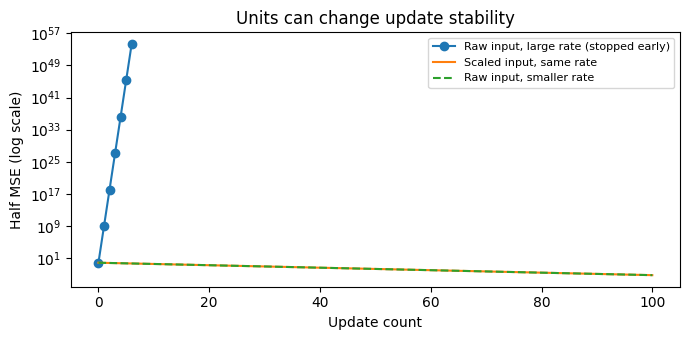

In [2]:
positions = torch.linspace(-1., 1., 40, dtype=torch.float64).reshape(-1, 1)
targets = 2 * positions

def fit_one_weight(inputs, rate, steps):
    weight = nn.Parameter(torch.zeros((), dtype=torch.float64))
    opt = torch.optim.SGD([weight], lr=rate)
    losses = []
    for _ in range(steps + 1):
        loss = 0.5 * (weight * inputs - targets).square().mean()
        losses.append(loss.item())
        if len(losses) <= steps:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
    return weight.detach(), np.array(losses)

raw_weight, raw_losses = fit_one_weight(1000 * positions, 0.1, 6)
scaled_weight, scaled_losses = fit_one_weight(positions, 0.1, 100)
small_rate_weight, small_rate_losses = fit_one_weight(1000 * positions, 1e-7, 100)
assert np.isfinite(raw_losses).all() and raw_losses[-1] > raw_losses[0]
assert scaled_losses[-1] < scaled_losses[0] / 100
torch.testing.assert_close(small_rate_weight * 1000, scaled_weight)
print(f"Raw input, rate 0.1: loss {raw_losses[0]:.6f} -> {raw_losses[-1]:.3e}")
print(f"Scaled input, rate 0.1: final loss {scaled_losses[-1]:.6f}")
print(f"Raw input, rate 0.0000001: final loss {small_rate_losses[-1]:.6f}")
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(raw_losses, 'o-', label='Raw input, large rate (stopped early)')
ax.semilogy(scaled_losses, label='Scaled input, same rate')
ax.semilogy(small_rate_losses, '--', label='Raw input, smaller rate')
ax.set(xlabel='Update count', ylabel='Half MSE (log scale)', title='Units can change update stability')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Give a curved task to a straight-line model

Generate a small noisy training set with the clean rule `reading = position²`. Validation examples are separate positions and independently generated noise. A straight line cannot express this bowl.

We fit the line directly by least squares, so a poor fit cannot be blamed on an unfinished optimizer run. A second simple baseline receives the squared position as its feature. `lstsq` finds the coefficients minimizing squared error; a column of ones supplies a bias. Only training targets enter either fit.

In [3]:
torch.manual_seed(42)
train_x = torch.linspace(-1., 1., 16).reshape(-1, 1)
train_y = train_x.square() + 0.22 * torch.randn_like(train_x)
validation_generator = torch.Generator().manual_seed(123)
val_x = torch.linspace(-0.98, 0.98, 100).reshape(-1, 1)
val_y = val_x.square() + 0.22 * torch.randn(val_x.shape, generator=validation_generator)

def design(x, squared=False):
    feature = x.square() if squared else x
    return torch.cat([feature, torch.ones_like(feature)], dim=1)

def mse(prediction, target):
    assert prediction.shape == target.shape
    return (prediction - target).square().mean()

baseline_results = {}
for name, squared in [('Straight line', False), ('Squared-feature line', True)]:
    coefficients = torch.linalg.lstsq(design(train_x, squared), train_y).solution
    train_score = mse(design(train_x, squared) @ coefficients, train_y).item()
    val_score = mse(design(val_x, squared) @ coefficients, val_y).item()
    baseline_results[name] = (coefficients, train_score, val_score)
    print(f'{name:22s}: train MSE={train_score:.5f}, validation MSE={val_score:.5f}')
assert baseline_results['Squared-feature line'][2] < baseline_results['Straight line'][2]

Straight line         : train MSE=0.25595, validation MSE=0.12494
Squared-feature line  : train MSE=0.05471, validation MSE=0.06460


## Watch a flexible model learn the curve and then the noise

The network has two hidden tanh layers. Tanh supplies smooth nonlinear bends. We use full-batch Adam updates so the learning curves are easy to interpret. Each recorded loss uses one fixed parameter state.

Validation selects a deep-copied snapshot, including the initial state as a candidate. We intentionally continue to a fixed budget to expose overfitting; this is checkpoint selection, not early stopping. The validation group is used for diagnosis and selection, so we do not call its error an unbiased final test score.

In [4]:
model = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 1))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
history = []
best_loss, best_step, best_state = float('inf'), None, None
for step in range(2001):
    model.eval()
    with torch.no_grad():
        train_loss = mse(model(train_x), train_y).item()
        val_loss = mse(model(val_x), val_y).item()
    history.append((train_loss, val_loss))
    if val_loss < best_loss:
        best_loss, best_step = val_loss, step
        best_state = copy.deepcopy(model.state_dict())
    if step < 2000:
        model.train()
        optimizer.zero_grad(set_to_none=True)
        mse(model(train_x), train_y).backward()
        optimizer.step()

history = np.array(history)
last_model = copy.deepcopy(model).eval()
model.load_state_dict(best_state)
model.eval()
assert np.isfinite(history).all()
assert history[-1, 0] < history[best_step, 0]
assert history[-1, 1] > best_loss
print(f'Selected update: {best_step}; validation MSE: {best_loss:.6f}')
print(f'Last update: training MSE {history[-1, 0]:.6f}; validation MSE {history[-1, 1]:.6f}')
print('The later model fits training data more closely but predicts validation data less well.')

Selected update: 30; validation MSE: 0.052480
Last update: training MSE 0.000056; validation MSE 0.113850
The later model fits training data more closely but predicts validation data less well.


## Put the curves beside the predictions

The left panel shows training and validation errors. On the right, compare the selected snapshot, final network, and simple squared-feature baseline. The dashed clean curve explains the generated world; it was not supplied as a training target.

Validation noise creates an error floor in expectation, not an exact lower bound on this finite sample. Fitting every training dot is not the goal when those dots contain noise.

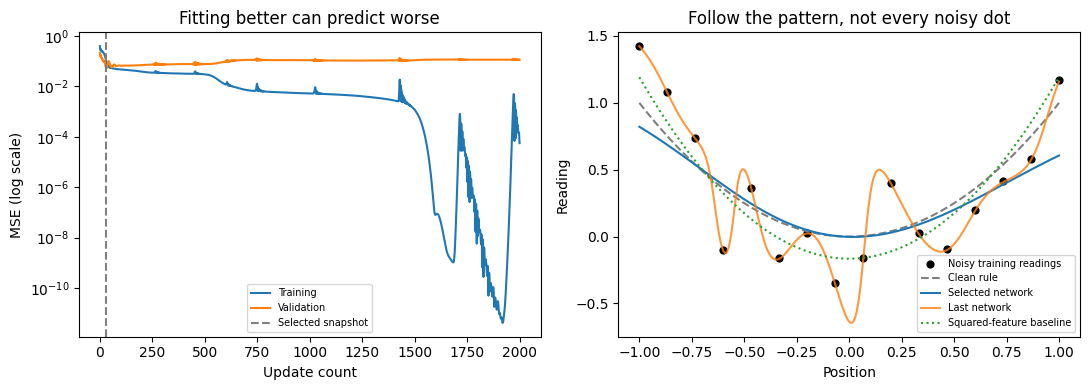

In [5]:
grid = torch.linspace(-1., 1., 250).reshape(-1, 1)
with torch.no_grad():
    chosen_curve = model(grid).numpy().ravel()
    last_curve = last_model(grid).numpy().ravel()
    simple_curve = (design(grid, True) @ baseline_results['Squared-feature line'][0]).numpy().ravel()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogy(history[:, 0], label='Training')
axes[0].semilogy(history[:, 1], label='Validation')
axes[0].axvline(best_step, color='gray', linestyle='--', label='Selected snapshot')
axes[0].set(xlabel='Update count', ylabel='MSE (log scale)', title='Fitting better can predict worse')
axes[1].scatter(train_x, train_y, s=24, color='black', label='Noisy training readings')
axes[1].plot(grid, grid.square(), '--', color='gray', label='Clean rule')
axes[1].plot(grid, chosen_curve, label='Selected network')
axes[1].plot(grid, last_curve, label='Last network', alpha=0.8)
axes[1].plot(grid, simple_curve, ':', label='Squared-feature baseline')
axes[1].set(xlabel='Position', ylabel='Reading', title='Follow the pattern, not every noisy dot')
for ax in axes: ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## See small and large gradient signals directly

A chain of multiplications isolates the chain rule. It is not a trained network: each link multiplies by a fixed factor, and we differentiate the final value with respect to the input. Repeated factors below one shrink the signal; factors above one enlarge it.

Gradient clipping rescales an oversized gradient before an update. The norm is the square root of the sum of squared entries. Clipping can limit a dangerous step, but it cannot restore a vanished signal or correct bad data.

In [6]:
for factor in [0.5, 2.0]:
    start = torch.tensor(1., dtype=torch.float64, requires_grad=True)
    end = start
    for _ in range(20):
        end = factor * end
    end.backward()
    torch.testing.assert_close(start.grad, torch.tensor(factor ** 20, dtype=torch.float64))
    print(f'Factor {factor}: input gradient = {start.grad.item():.8g}')

parameter = nn.Parameter(torch.tensor([3., 4.]))
parameter.grad = torch.tensor([30., 40.])
old_gradient = parameter.grad.clone()
reported_norm = nn.utils.clip_grad_norm_([parameter], max_norm=1.)
assert torch.isclose(reported_norm, torch.tensor(50.))
assert parameter.grad.norm() <= 1.000001
torch.testing.assert_close(parameter.grad, old_gradient / 50., atol=1e-6, rtol=1e-6)
print('Before clipping:', old_gradient.tolist(), '| norm:', reported_norm.item())
print('After clipping:', parameter.grad.tolist(), '| norm:', parameter.grad.norm().item())

Factor 0.5: input gradient = 9.5367432e-07
Factor 2.0: input gradient = 1048576


Before clipping: [30.0, 40.0] | norm: 50.0
After clipping: [0.5999999642372131, 0.7999999523162842] | norm: 0.9999999403953552


## Make an inactive ReLU visible

ReLU returns zero for negative inputs. Here its score is negative for every example, so the weight receives zero gradient despite a nonzero loss. Leaky ReLU uses a small negative-side slope, keeping a signal in this particular case. This isolated comparison does not prove it is always the better activation.

In [7]:
for name, activation in [('ReLU', nn.ReLU()), ('Leaky ReLU', nn.LeakyReLU(0.1))]:
    weight = nn.Parameter(torch.tensor(-1.))
    prediction = activation(weight * torch.tensor(1.))
    loss = 0.5 * (prediction - 1.).square()
    loss.backward()
    print(f'{name:10s}: prediction={prediction.item():.2f}, loss={loss.item():.3f}, gradient={weight.grad.item():.3f}')
    if name == 'ReLU':
        assert weight.grad.item() == 0 and loss.item() > 0
    else:
        assert weight.grad.item() < 0

ReLU      : prediction=0.00, loss=0.500, gradient=0.000
Leaky ReLU: prediction=-0.10, loss=0.605, gradient=-0.110


## Verify the repair mechanism on a tiny batch

A tiny-batch fit can reveal whether the basic prediction → loss → backward → update path works. This diagnostic is deliberately easy and separate from validation. Passing it does not establish generalization.

We fit a line to four exact pairs with a known linear relationship. Every iteration checks matching shapes and finite loss. The final assertion checks that the intended easy problem can be fitted.

In [8]:
tiny_x = torch.tensor([[-1.], [-0.3], [0.3], [1.]])
tiny_y = 2 * tiny_x + 0.5
tiny_model = nn.Linear(1, 1)
tiny_optimizer = torch.optim.SGD(tiny_model.parameters(), lr=0.1)
for _ in range(200):
    tiny_optimizer.zero_grad(set_to_none=True)
    tiny_loss = mse(tiny_model(tiny_x), tiny_y)
    assert torch.isfinite(tiny_loss)
    tiny_loss.backward()
    tiny_optimizer.step()
with torch.no_grad():
    final_tiny_loss = mse(tiny_model(tiny_x), tiny_y).item()
assert final_tiny_loss < 1e-8
print(f'Tiny-batch MSE: {final_tiny_loss:.3e}')
print('All controlled demonstrations and arithmetic checks passed.')

Tiny-batch MSE: 1.192e-13
All controlled demonstrations and arithmetic checks passed.


## Interpret the evidence before choosing a fix

Scaling the input or reducing the learning rate repaired our unstable scalar update. Adding the squared feature repaired the straight line's mismatch with a curved task. Selecting an earlier checkpoint avoided the later network's worse validation error. The gradient demonstrations exposed weak, oversized, and inactive signals without pretending that one remedy solves every cause.

These are deliberately constructed examples. We used validation to inspect and select models, and kept no final test set in this diagnostic notebook. A real comparison would fix its choices and then evaluate on untouched test data. All settings here illustrate mechanisms rather than recommendations for every dataset.

In [ ]:
import torch.nn.functional as F

torch.manual_seed(22)
x_reg = torch.linspace(-1, 1, 40).unsqueeze(1)
y_reg = x_reg.square() + 0.12 * torch.randn_like(x_reg)
strengths = [0., 1e-4, 0.05, 1.]
validation_losses = []
for strength in strengths:
    torch.manual_seed(23)
    model = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 1))
    opt = torch.optim.Adam(model.parameters(), lr=.03, weight_decay=strength)
    for _ in range(150):
        opt.zero_grad(set_to_none=True)
        loss = F.mse_loss(model(x_reg), y_reg)
        loss.backward(); opt.step()
    validation_losses.append(F.mse_loss(model(torch.tensor([[-.8], [.8]])), torch.tensor([[.64], [.64]])).item())
print(dict(zip(strengths, validation_losses)))
assert all(torch.isfinite(torch.tensor(validation_losses)))

# A fresh mask is used in train mode and no mask in evaluation mode.
dropout = nn.Dropout(.4)
dropout.train(); torch.manual_seed(7); noisy = dropout(torch.ones(1000))
dropout.eval(); stable = dropout(torch.ones(1000))
assert noisy.unique().numel() > 1 and torch.allclose(stable, torch.ones_like(stable))
print('dropout train mean:', noisy.mean().item(), '| eval value:', stable[0].item())